In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
csv_path = "deploy_blockers.csv"
df = pd.read_csv(csv_path)
df.drop(columns=["StagingDeployCash Issue"])

,Deploy Blocker Issue Number,Deploy Blocker GitHub URL,StagingDeployCash Issue Number,StagingDeployCash GitHub URL,StagingDeployCash Created At
0,62669,https://github.com/Expensify/App/issues/62669,62662,https://github.com/Expensify/App/issues/62662,2025-05-23
1,62672,https://github.com/Expensify/App/issues/62672,62662,https://github.com/Expensify/App/issues/62662,2025-05-23
2,62674,https://github.com/Expensify/App/issues/62674,62662,https://github.com/Expensify/App/issues/62662,2025-05-23
3,62675,https://github.com/Expensify/App/issues/62675,62662,https://github.com/Expensify/App/issues/62662,2025-05-23
4,62676,https://github.com/Expensify/App/issues/62676,62662,https://github.com/Expensify/App/issues/62662,2025-05-23
...,...,...,...,...,...
5628,4284,https://github.com/Expensify/App/issues/4284,4279,https://github.com/Expensify/App/issues/4279,2021-07-28
5629,4293,https://github.com/Expensify/App/issues/4293,4279,https://github.com/Expensify/App/issues/4279,2021-07-28
5630,4207,https://github.com/Expensify/App/issues/4207,4198,https://github.com/Expensify/App/issues/4198,2021-07-23
5631,4208,https://github.com/Expensify/App/issues/4208,4198,https://github.com/Expensify/App/issues/4198,2021-07-23


In [4]:
df.head()

,Deploy Blocker Issue Number,Deploy Blocker GitHub URL,StagingDeployCash Issue,StagingDeployCash Issue Number,StagingDeployCash GitHub URL,StagingDeployCash Created At
0,62669,https://github.com/Expensify/App/issues/62669,Deploy Checklist: New Expensify 2025-05-23,62662,https://github.com/Expensify/App/issues/62662,2025-05-23
1,62672,https://github.com/Expensify/App/issues/62672,Deploy Checklist: New Expensify 2025-05-23,62662,https://github.com/Expensify/App/issues/62662,2025-05-23
2,62674,https://github.com/Expensify/App/issues/62674,Deploy Checklist: New Expensify 2025-05-23,62662,https://github.com/Expensify/App/issues/62662,2025-05-23
3,62675,https://github.com/Expensify/App/issues/62675,Deploy Checklist: New Expensify 2025-05-23,62662,https://github.com/Expensify/App/issues/62662,2025-05-23
4,62676,https://github.com/Expensify/App/issues/62676,Deploy Checklist: New Expensify 2025-05-23,62662,https://github.com/Expensify/App/issues/62662,2025-05-23


In [5]:
blocker_counts = df.groupby(["StagingDeployCash Issue Number", "StagingDeployCash GitHub URL", "StagingDeployCash Created At"]) \
                   .size().reset_index(name="Deploy Blocker Count")
blocker_counts

,StagingDeployCash Issue Number,StagingDeployCash GitHub URL,StagingDeployCash Created At,Deploy Blocker Count
0,4198,https://github.com/Expensify/App/issues/4198,2021-07-23,3
1,4279,https://github.com/Expensify/App/issues/4279,2021-07-28,2
2,4333,https://github.com/Expensify/App/issues/4333,2021-07-30,4
3,4447,https://github.com/Expensify/App/issues/4447,2021-08-06,6
4,4554,https://github.com/Expensify/App/issues/4554,2021-08-11,11
...,...,...,...,...
475,61917,https://github.com/Expensify/App/issues/61917,2025-05-13,55
476,62161,https://github.com/Expensify/App/issues/62161,2025-05-16,23
477,62353,https://github.com/Expensify/App/issues/62353,2025-05-20,14
478,62497,https://github.com/Expensify/App/issues/62497,2025-05-21,29


In [6]:
average_blockers = blocker_counts["Deploy Blocker Count"].mean()
average_blockers

np.float64(11.735416666666667)

In [7]:
df["StagingDeployCash Created At"] = pd.to_datetime(df["StagingDeployCash Created At"])
unique_deploys = df[["StagingDeployCash Issue Number", "StagingDeployCash Created At"]].drop_duplicates()


In [8]:
unique_deploys["Year"] = unique_deploys["StagingDeployCash Created At"].dt.year
unique_deploys["Month"] = unique_deploys["StagingDeployCash Created At"].dt.month

# Group by year and month
deploys_per_month_year = unique_deploys.groupby(["Year", "Month"]).size().reset_index(name="Deploy Count")

deploys_per_month_year

,Year,Month,Deploy Count
0,2021,7,3
1,2021,8,4
2,2021,9,12
3,2021,10,6
4,2021,11,5
5,2021,12,7
6,2022,1,7
7,2022,2,4
8,2022,3,6
9,2022,4,5


In [9]:
average_deploys_per_month = deploys_per_month_year["Deploy Count"].mean()
average_deploys_per_month

np.float64(10.212765957446809)

In [10]:
df["Year"] = df["StagingDeployCash Created At"].dt.year
df["Month"] = df["StagingDeployCash Created At"].dt.month

# Group by year and month, count deploy blockers
blockers_per_month = df.groupby(["Year", "Month"]).size().reset_index(name="Deploy Blocker Count")
blockers_per_month

,Year,Month,Deploy Blocker Count
0,2021,7,9
1,2021,8,42
2,2021,9,29
3,2021,10,22
4,2021,11,31
5,2021,12,37
6,2022,1,16
7,2022,2,12
8,2022,3,22
9,2022,4,17


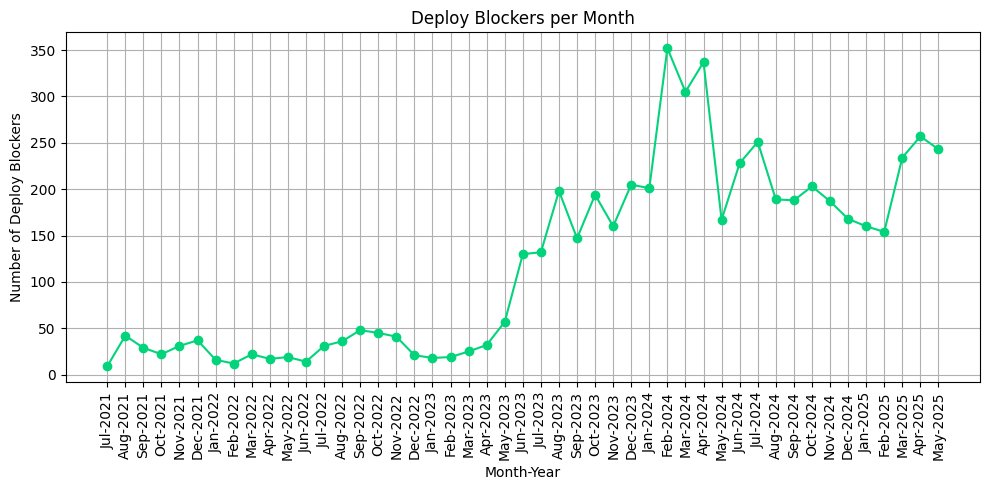

In [16]:
import calendar

# Create formatted month labels like 'Jul-2021'
formatted_labels = [
    f"{calendar.month_abbr[int(month)]}-{year}"
    for month, year in zip(blockers_per_month["Month"], blockers_per_month["Year"])
]


plt.figure(figsize=(10, 5))
plt.plot(
    formatted_labels,
    blockers_per_month["Deploy Blocker Count"],
    marker='o',
    linestyle='-',
    color='#03d47c'
)
plt.title("Deploy Blockers per Month")
plt.xlabel("Month-Year")
plt.ylabel("Number of Deploy Blockers")
plt.grid(True)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



In [24]:
df["StagingDeployCash Created At"] = pd.to_datetime(df["StagingDeployCash Created At"])

df["Year-Week"] = df["StagingDeployCash Created At"].dt.strftime("%Y-%U")

blockers_per_week = df.groupby("Year-Week").size().reset_index(name="Deploy Blocker Count")

average_blockers_per_week = blockers_per_week["Deploy Blocker Count"].mean()
average_blockers_per_week


np.float64(29.036082474226806)

In [25]:
median_blockers_per_week = blockers_per_week["Deploy Blocker Count"].median()
median_blockers_per_week


np.float64(20.5)

In [26]:
# Extract Year-Month for grouping
df["Year-Month"] = df["StagingDeployCash Created At"].dt.to_period("M")

# Count blockers per month
blockers_per_month = df.groupby("Year-Month").size().reset_index(name="Deploy Blocker Count")

# Calculate average blockers per month
average_blockers_per_month = blockers_per_month["Deploy Blocker Count"].mean()
average_blockers_per_month


np.float64(119.85106382978724)

In [27]:
median_blockers_per_month = blockers_per_month["Deploy Blocker Count"].median()
median_blockers_per_month


np.float64(130.0)